# SM2RAIN Irrigation Estimation

This notebook computes **daily and monthly irrigation estimates** for every SMAP grid point
using the per-class SM2RAIN parameters calibrated in `5_per_class_optimizer.ipynb`.

**Pipeline:**
1. Load calibrated per-class parameters (`Zstar`, `Ks`, `λ`, `Kc`)
2. Load SMAP soil moisture, temperature, and precipitation data
3. For each grid point assign it to its rainfall class → pick matching parameters
4. Run SM2RAIN forward model over the full period → total water input
5. Subtract reference rainfall → daily irrigation estimate
6. Aggregate to monthly and save to CSV (separate directories for daily / monthly)


## 1. Import Libraries & Configuration

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import netCDF4 as nc
import xarray as xr
from pathlib import Path
from datetime import datetime, timedelta
import warnings
import os
import json
from scipy.spatial import cKDTree
import sys
from tqdm import tqdm

warnings.filterwarnings('ignore')

# ── Add parent directory so that main.py / utils.py / data_preprocessor.py are importable ──
sys.path.append(str(Path.cwd()))          # for notebook run inside the project root
sys.path.append(str(Path.cwd().parent))   # fallback when cwd is calibration/

# ──────────────────────────── FILE PATHS ────────────────────────────
SMAP_FILE          = Path(r'G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc')
CLASSIFICATION_FILE= Path(r'G:\SM2RAIN-irrigation_Final\calibration\SM_classes\SM_classes_ludhiana.csv')
PARAMS_DIR         = Path(r'G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana')
TEMP_FILE          = Path(r'G:\SM2RAIN-irrigation_Final\data\temp_data\AgERA5_daily_mean_ludhiana.nc')
PRECIP_FILE        = Path(r'G:\SM2RAIN-irrigation_Final\data\precipitation_data\GPM_IMERG_ludhiana_final_run.nc')

# ──────────────────────────── OUTPUT DIRS ───────────────────────────
BASE_OUTPUT        = Path(r'G:\SM2RAIN-irrigation_Final\irrigation_output')
DAILY_OUTPUT_DIR   = BASE_OUTPUT / 'daily_irrigation_estimates_new'
MONTHLY_OUTPUT_DIR = BASE_OUTPUT / 'monthly_irrigation_estimates_new'
FIGURES_DIR        = BASE_OUTPUT / 'figures'

for d in [DAILY_OUTPUT_DIR, MONTHLY_OUTPUT_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ──────────────────────────── CONSTANTS ─────────────────────────────
T_EXPONENTIAL_FILTER = 5.0    # days  (must match the calibration setting)
FILL_VALUE           = -9999.0
SM_SOURCE            = 'BOTH' # 'AM', 'PM', or 'BOTH'
NUM_CLASSES          = 5
COORD_TOLERANCE      = 0.001  # degrees  (for coordinate matching)
IRRIGATION_THRESHOLD = 0.0    # mm/day   (0 = keep all positive residuals)

print("Configuration loaded.")
print(f"  SMAP file       : {SMAP_FILE}")
print(f"  Parameters dir  : {PARAMS_DIR}")
print(f"  Daily output    : {DAILY_OUTPUT_DIR}")
print(f"  Monthly output  : {MONTHLY_OUTPUT_DIR}")


Configuration loaded.
  SMAP file       : G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc
  Parameters dir  : G:\SM2RAIN-irrigation_Final\calibration\per_class_parameters_ludhiana
  Daily output    : G:\SM2RAIN-irrigation_Final\irrigation_output\daily_irrigation_estimates_new
  Monthly output  : G:\SM2RAIN-irrigation_Final\irrigation_output\monthly_irrigation_estimates_new


## 2. Load Calibrated Per-Class Parameters

In [63]:

# ════════════════════════════════════════════════════════════════════
#  PARAMETER MODE CONFIGURATION
#  Choose one of three modes:
#
#   'calibrated'   – use the per-class parameters from the JSON file (default)
#   'global_class' – use ONE class's calibrated parameters for ALL classes
#   'hardcoded'    – ignore the JSON file; use the values you type below
# ════════════════════════════════════════════════════════════════════
PARAM_MODE = 'global_class'   # ← set to 'calibrated' | 'global_class' | 'hardcoded'

# ── Used only when PARAM_MODE = 'global_class' ──────────────────────
# Whichever class id you set here will supply its parameters to every class.
GLOBAL_CLASS_ID = 5   # ← set to any valid class id (1–5)

# ── Used only when PARAM_MODE = 'hardcoded' ─────────────────────────
# Fill in Zstar, Ks, lam, Kc for every class you want to override.
# Classes not listed here will fall back to calibrated values.
HARDCODED_PARAMS = {
    1: {'Zstar': 50.0,  'Ks': 2.0,   'lam': 1.5,  'Kc': 0.5},
    2: {'Zstar': 60.0,  'Ks': 2.5,   'lam': 1.6,  'Kc': 0.6},
    3: {'Zstar': 55.0,  'Ks': 2.2,   'lam': 1.4,  'Kc': 0.55},
    4: {'Zstar': 45.0,  'Ks': 1.8,   'lam': 1.3,  'Kc': 0.45},
    5: {'Zstar': 70.0,  'Ks': 3.0,   'lam': 1.7,  'Kc': 0.65},
}
# ════════════════════════════════════════════════════════════════════

# ── Load the combined results JSON written by 5_per_class_optimizer ─
all_results_file = PARAMS_DIR / 'all_classes_calibration_results.json'

if not all_results_file.exists():
    raise FileNotFoundError(
        f"Calibration results not found: {all_results_file}\n"
        "Please run 5_per_class_optimizer.ipynb first."
    )

with open(all_results_file, 'r') as f:
    all_class_results_raw = json.load(f)

# ── Extract best_parameters for each class (always loaded as baseline) ─
class_params = {}   # { class_id (int) : {'Zstar':..., 'Ks':..., 'lam':..., 'Kc':...} }
for class_key, results in all_class_results_raw.items():
    class_id = int(class_key)
    class_params[class_id] = {
        'Zstar': results['best_parameters']['Zstar'],
        'Ks':    results['best_parameters']['Ks'],
        'lam':   results['best_parameters']['lam'],
        'Kc':    results['best_parameters']['Kc'],
    }

# ── Apply parameter mode overrides ───────────────────────────────────
if PARAM_MODE == 'global_class':
    if GLOBAL_CLASS_ID not in class_params:
        raise ValueError(
            f"GLOBAL_CLASS_ID={GLOBAL_CLASS_ID} not found in calibration results. "
            f"Available: {sorted(class_params.keys())}"
        )
    global_p = class_params[GLOBAL_CLASS_ID].copy()
    print(f"[PARAM_MODE = global_class]  "
          f"Using Class {GLOBAL_CLASS_ID} parameters for ALL classes:")
    print(f"  Zstar={global_p['Zstar']:.4f}  Ks={global_p['Ks']:.4f}  "
          f"lam={global_p['lam']:.4f}  Kc={global_p['Kc']:.4f}")
    for cid in class_params:
        class_params[cid] = global_p.copy()

elif PARAM_MODE == 'hardcoded':
    print("[PARAM_MODE = hardcoded]  Overriding class parameters:")
    for cid, hp in HARDCODED_PARAMS.items():
        if cid in class_params:
            class_params[cid] = {k: float(v) for k, v in hp.items()}
            print(f"  Class {cid}: Zstar={hp['Zstar']}  Ks={hp['Ks']}  "
                  f"lam={hp['lam']}  Kc={hp['Kc']}")
        else:
            print(f"  Class {cid}: NOT in calibration data – skipped.")

else:   # 'calibrated'
    print("[PARAM_MODE = calibrated]  Using per-class calibrated parameters.")

# ── Summary table ────────────────────────────────────────────────────
summary_rows = []
for cid in sorted(class_params.keys()):
    p = class_params[cid]
    res = all_class_results_raw[str(cid)]
    summary_rows.append({
        'Class': cid,
        'Zstar': round(p['Zstar'], 4),
        'Ks':    round(p['Ks'],    4),
        'lam':   round(p['lam'],   4),
        'Kc':    round(p['Kc'],    4),
        'Best_KGE':  round(res.get('best_kge',  float('nan')), 4),
        'Best_RMSE': round(res.get('best_rmse', float('nan')), 4),
    })

params_df = pd.DataFrame(summary_rows)
print(f"\nEffective parameters for all classes (mode = '{PARAM_MODE}'):\n")
print(params_df.to_string(index=False))
print(f"\nTotal classes loaded: {len(class_params)}")


[PARAM_MODE = global_class]  Using Class 5 parameters for ALL classes:
  Zstar=153.5157  Ks=59.7263  lam=15.0000  Kc=0.0000

Effective parameters for all classes (mode = 'global_class'):

 Class    Zstar      Ks  lam  Kc  Best_KGE  Best_RMSE
     1 153.5157 59.7263 15.0 0.0    0.3871    13.9289
     2 153.5157 59.7263 15.0 0.0    0.3767    13.9648
     3 153.5157 59.7263 15.0 0.0    0.3667    15.6856
     4 153.5157 59.7263 15.0 0.0    0.4615    18.6067
     5 153.5157 59.7263 15.0 0.0    0.4979    17.1811

Total classes loaded: 5


## 3. Load SMAP Soil Moisture Data

In [64]:
def load_smap_data(smap_file, sm_source='BOTH', fill_value=-9999.0):
    """
    Load SMAP soil moisture from the SPL3SMP_E NetCDF.
    Returns a flat DataFrame:  time | date | latitude | longitude | soil_moisture
    """
    print(f"Loading SMAP data from: {smap_file}")
    ds = nc.Dataset(smap_file, 'r')

    epoch     = datetime(2000, 1, 1)
    time_j2000 = ds.variables['time'][:]
    time_dt   = np.array([epoch + timedelta(seconds=float(t)) for t in time_j2000])

    latitude        = ds.variables['latitude'][:]
    longitude       = ds.variables['longitude'][:]
    soil_moisture_am = ds.variables['soil_moisture_am'][:]
    soil_moisture_pm = ds.variables['soil_moisture_pm'][:]
    ds.close()

    df = pd.DataFrame({
        'time':          time_dt,
        'latitude':      latitude,
        'longitude':     longitude,
        'soil_moisture_am': soil_moisture_am,
        'soil_moisture_pm': soil_moisture_pm,
    })

    # Remove fill values
    df = df[(df['latitude'] != fill_value) & (df['longitude'] != fill_value)]
    df = df[(df['soil_moisture_am'] != fill_value) | (df['soil_moisture_pm'] != fill_value)]

    # Combine AM / PM
    if sm_source == 'AM':
        df['soil_moisture'] = df['soil_moisture_am'].replace(fill_value, np.nan)
    elif sm_source == 'PM':
        df['soil_moisture'] = df['soil_moisture_pm'].replace(fill_value, np.nan)
    else:  # BOTH
        sm_am = df['soil_moisture_am'].replace(fill_value, np.nan)
        sm_pm = df['soil_moisture_pm'].replace(fill_value, np.nan)
        df['soil_moisture'] = np.nanmean([sm_am, sm_pm], axis=0)

    df = df.dropna(subset=['soil_moisture'])
    df['date'] = pd.to_datetime(df['time']).dt.date

    print(f"  Loaded {len(df):,} valid observations")
    print(f"  Date range: {df['time'].min()} to {df['time'].max()}")
    print(f"  Unique locations: {df.groupby(['latitude', 'longitude']).ngroups}")
    print(f"  Lat range : {df['latitude'].min():.4f} – {df['latitude'].max():.4f}")
    print(f"  Lon range : {df['longitude'].min():.4f} – {df['longitude'].max():.4f}")
    return df


# Load SMAP data
smap_df = load_smap_data(SMAP_FILE, SM_SOURCE, FILL_VALUE)
print("\nFirst few rows:")
print(smap_df[['time', 'date', 'latitude', 'longitude', 'soil_moisture']].head())


Loading SMAP data from: G:\SM2RAIN-irrigation_Final\data\SMAP_data\SPL3SMP_E_Ludhiana_ROI.nc
  Loaded 288,684 valid observations
  Date range: 2015-04-03 00:00:00 to 2025-12-31 00:00:00
  Unique locations: 156
  Lat range : 30.0269 – 31.0071
  Lon range : 75.0156 – 76.0425

First few rows:
        time        date   latitude  longitude  soil_moisture
0 2015-04-03  2015-04-03  31.007128  75.015564       0.202547
1 2015-04-03  2015-04-03  31.007128  75.108925       0.216642
2 2015-04-03  2015-04-03  31.007128  75.202286       0.195568
3 2015-04-03  2015-04-03  31.007128  75.295647       0.180963
4 2015-04-03  2015-04-03  31.007128  75.389008       0.182054


## 4. Load Classification Data

In [65]:
classification_df = pd.read_csv(CLASSIFICATION_FILE)
print(f"Classification data: {len(classification_df)} records")
print(f"Columns: {list(classification_df.columns)}")
print(f"\nClass distribution:")
print(classification_df['rainfall_class'].value_counts().sort_index())

# ── Build (lat, lon) → class_id lookup ──────────────────────────────
# Round coordinates to 4 dp to avoid floating-point mismatch with SMAP
classification_df['lat_r'] = classification_df['latitude'].round(4)
classification_df['lon_r'] = classification_df['longitude'].round(4)

coord_to_class = {
    (row['lat_r'], row['lon_r']): int(row['rainfall_class'])
    for _, row in classification_df.iterrows()
}

print(f"\nLookup table built: {len(coord_to_class)} grid points → classes")
print(f"Unique classes in lookup: {sorted(set(coord_to_class.values()))}")


Classification data: 156 records
Columns: ['latitude', 'longitude', 'rainfall_class', 'grid_cell_index']

Class distribution:
rainfall_class
1    25
2    16
3    42
4    41
5    32
Name: count, dtype: int64

Lookup table built: 156 grid points → classes
Unique classes in lookup: [1, 2, 3, 4, 5]


## 5. Load & Resample Temperature and Precipitation to SMAP Grid

In [66]:

def load_netcdf_gridded_data(file_path, var_name=None):
    """
    Load gridded NetCDF (temperature or precipitation) into a flat DataFrame.

    Reading strategy (tries each in order until one succeeds):
      1. netCDF4 direct  - full [:] read into NumPy, CF time decoded via
                           netCDF4.num2date so xarray lazy-loading is never used.
      2. h5py direct     - for files where netCDF4 raises HDF errors.
      3. GPM IMERG       - char-array 'date' variable (DD-MM-YYYY).

    Returns (df, None) where df has columns: lat, lon, time, date, value
    """
    file_path = str(file_path)
    print(f"Loading: {file_path}")

    lat_names  = ['lat', 'latitude', 'y']
    lon_names  = ['lon', 'longitude', 'x']
    time_names = ['time', 'date']
    var_candidates = [
        'Temperature_Air_2m_Mean_24h', 'temperature', 'temp', 't2m', 'tas',
        'precipitation', 'precip', 'tp', 'pr', 'precipitationCal',
    ]

    # Collect errors from each strategy so they survive Python 3's except-scoping
    _errors = []

    # ── helpers ────────────────────────────────────────────────────────
    def _build_df(data_np, lats, lons, times_pd):
        """Meshgrid -> flat DataFrame."""
        n_t, n_lat, n_lon = data_np.shape
        ti, li, ni = np.meshgrid(np.arange(n_t), np.arange(n_lat), np.arange(n_lon),
                                  indexing='ij')
        df = pd.DataFrame({
            'time':  times_pd[ti.ravel()],
            'lat':   np.asarray(lats)[li.ravel()],
            'lon':   np.asarray(lons)[ni.ravel()],
            'value': np.asarray(data_np).ravel(),
        })
        df = df.dropna(subset=['time', 'value'])
        df['time'] = pd.to_datetime(df['time'])
        df['date'] = df['time'].dt.date
        return df

    def _detect_var(var_names_in_file):
        if var_name is not None:
            return var_name
        v = next((c for c in var_candidates if c in var_names_in_file), None)
        if v is None:
            raise ValueError(f"Cannot auto-detect variable. Available: {list(var_names_in_file)}")
        return v

    def _find_dim(dims, name_list):
        return next((d for d in dims if d in name_list), None)

    # ── Strategy 1 : netCDF4 direct ────────────────────────────────────
    try:
        print("  [Strategy 1] netCDF4 direct read …")
        ds = nc.Dataset(file_path, 'r')
        try:
            vn = _detect_var(ds.variables.keys())
            print(f"  Variable: {vn}")
            dims = ds.variables[vn].dimensions
            lat_dim  = _find_dim(dims, lat_names)
            lon_dim  = _find_dim(dims, lon_names)
            time_dim = _find_dim(dims, time_names)
            if not all([lat_dim, lon_dim, time_dim]):
                raise ValueError(f"Cannot identify lat/lon/time dims: {dims}")

            # Read everything into NumPy immediately (no lazy HDF5 reads)
            data_np  = np.ma.filled(ds.variables[vn][:], np.nan)
            lats     = np.array(ds.variables[lat_dim][:])
            lons     = np.array(ds.variables[lon_dim][:])

            time_raw = None
            t_units  = None
            t_cal    = 'standard'
            if time_dim in ds.variables:
                time_var = ds.variables[time_dim]
                time_raw = np.array(time_var[:])
                t_units  = getattr(time_var, 'units',    None)
                t_cal    = getattr(time_var, 'calendar', 'standard')
            elif 'date' in ds.variables:
                time_raw = np.array(ds.variables['date'][:])
            else:
                raise ValueError("Time dimension exists but no time/date variable found.")
        finally:
            ds.close()

        # Decode times
        if t_units and 'since' in str(t_units):
            try:
                cf_dates = nc.num2date(time_raw, units=t_units, calendar=t_cal)
                times_pd = pd.to_datetime(
                    [d.strftime('%Y-%m-%d') if hasattr(d, 'strftime') else str(d)
                     for d in cf_dates],
                    errors='coerce'
                )
            except Exception:
                times_pd = pd.to_datetime(time_raw, unit='D', origin='unix', errors='coerce')
        else:
            times_pd = _parse_gpm_char_dates(time_raw)

        df = _build_df(data_np, lats, lons, times_pd)
        print(f"  Records: {len(df):,}  |  "
              f"Unique locs: {df.groupby(['lat','lon']).ngroups}  |  "
              f"{df['time'].min().date()} – {df['time'].max().date()}")
        return df, None

    except Exception as _e:
        _errors.append(f"Strategy 1 (netCDF4 direct): {_e}")
        print(f"  [Strategy 1 failed] {_e}")

    # ── Strategy 2 : h5py direct ───────────────────────────────────────
    try:
        import h5py
        print("  [Strategy 2] h5py direct read …")
        with h5py.File(file_path, 'r') as hf:
            def _iter_vars(g, prefix=''):
                for k in g.keys():
                    full = f"{prefix}/{k}" if prefix else k
                    if isinstance(g[k], h5py.Dataset):
                        yield full
                    else:
                        yield from _iter_vars(g[k], full)

            all_keys = list(_iter_vars(hf))
            vn = _detect_var(all_keys)
            print(f"  Variable: {vn}")
            data_np = hf[vn][()]  # read fully into NumPy

            # Locate lat / lon / time by name
            def _find_coord(hf_root, name_list):
                for nk in name_list:
                    if nk in hf_root:
                        return np.array(hf_root[nk][()])
                for k in all_keys:
                    if k.split('/')[-1] in name_list:
                        return np.array(hf_root[k][()])
                return None

            lats     = _find_coord(hf, lat_names)
            lons     = _find_coord(hf, lon_names)
            time_raw = _find_coord(hf, time_names)
            if lats is None or lons is None or time_raw is None:
                raise ValueError("Could not locate lat/lon/time in h5py keys.")
            if np.asarray(time_raw).size == 0:
                raise ValueError("Time/date variable is empty.")

            t_units = None
            t_cal   = 'standard'
            for tn in time_names:
                if tn in hf:
                    t_units = hf[tn].attrs.get('units', None)
                    t_cal   = hf[tn].attrs.get('calendar', 'standard')
                    if t_units:
                        t_units = t_units.decode() if isinstance(t_units, bytes) else str(t_units)
                    if isinstance(t_cal, bytes):
                        t_cal = t_cal.decode()
                    elif isinstance(t_cal, str) and t_cal.startswith("b'") and t_cal.endswith("'"):
                        t_cal = t_cal[2:-1]
                    break

        if t_units and 'since' in str(t_units):
            cf_dates = nc.num2date(time_raw, units=t_units, calendar=t_cal)
            times_pd = pd.to_datetime(
                [d.strftime('%Y-%m-%d') if hasattr(d, 'strftime') else str(d)
                 for d in cf_dates], errors='coerce')
        else:
            times_pd = _parse_gpm_char_dates(time_raw)

        if data_np.ndim != 3:
            raise ValueError(f"Expected 3-D array, got shape {data_np.shape}")
        data_np = data_np.astype(float)
        data_np[np.abs(data_np) > 1e36] = np.nan

        df = _build_df(data_np, lats, lons, times_pd)
        print(f"  Records: {len(df):,}  |  "
              f"Unique locs: {df.groupby(['lat','lon']).ngroups}  |  "
              f"{df['time'].min().date()} – {df['time'].max().date()}")
        return df, None

    except Exception as _e:
        _errors.append(f"Strategy 2 (h5py direct):    {_e}")
        print(f"  [Strategy 2 failed] {_e}")

    raise RuntimeError(
        f"All loading strategies failed for {file_path}.\n" +
        "\n".join(_errors)
    )


def _parse_gpm_char_dates(time_raw):
    """Parse GPM-style date arrays into datetime (supports 1-D or 2-D arrays)."""
    if time_raw is None:
        return pd.to_datetime([], errors='coerce')
    time_arr = np.asarray(time_raw)
    if time_arr.size == 0:
        return pd.to_datetime([], errors='coerce')

    # 1-D array of strings/bytes
    if time_arr.ndim == 1:
        parsed = []
        for item in time_arr:
            try:
                if hasattr(item, 'decode'):
                    date_str = item.decode('utf-8').strip()
                else:
                    date_str = str(item).strip()
                if not date_str:
                    parsed.append(pd.NaT)
                    continue
                try:
                    parsed.append(datetime.strptime(date_str, '%d-%m-%Y'))
                except Exception:
                    parsed.append(datetime.strptime(date_str, '%Y-%m-%d'))
            except Exception:
                parsed.append(pd.NaT)
        return pd.to_datetime(parsed, errors='coerce')

    # 2-D char array shaped (N, 10)
    parsed = []
    for i in range(time_arr.shape[0]):
        row = time_arr[i]
        try:
            if row.size == 0:
                parsed.append(pd.NaT)
                continue
            if hasattr(row.flat[0], 'decode'):
                date_str = b''.join(row).decode('utf-8').strip()
            else:
                date_str = ''.join(str(c) for c in row).strip()
            if not date_str:
                parsed.append(pd.NaT)
                continue
            try:
                parsed.append(datetime.strptime(date_str, '%d-%m-%Y'))
            except Exception:
                parsed.append(datetime.strptime(date_str, '%Y-%m-%d'))
        except Exception:
            parsed.append(pd.NaT)
    return pd.to_datetime(parsed, errors='coerce')


def resample_to_smap_grid(source_df, smap_coords):
    """
    Nearest-neighbour resample source data onto the SMAP grid.
    Returns DataFrame with smap_lat, smap_lon, time, date, value columns.
    """
    print("\nResampling to SMAP grid …")
    source_pts   = source_df[['lat', 'lon']].drop_duplicates().values
    smap_pts_arr = smap_coords[['latitude', 'longitude']].values

    tree = cKDTree(source_pts)
    dists, idxs = tree.query(smap_pts_arr)
    print(f"  Source pts: {len(source_pts)}  |  SMAP pts: {len(smap_pts_arr)}")
    print(f"  Max NN dist: {dists.max():.4f}°  |  Mean: {dists.mean():.4f}°")

    mapping = {}
    for i, (slat, slon) in enumerate(smap_pts_arr):
        src_lat, src_lon = source_pts[idxs[i]]
        mapping[(slat, slon)] = (src_lat, src_lon)

    parts = []
    for (slat, slon), (src_lat, src_lon) in mapping.items():
        subset = source_df[
            (source_df['lat'] == src_lat) & (source_df['lon'] == src_lon)
        ].copy()
        if len(subset) > 0:
            subset = subset.assign(smap_lat=slat, smap_lon=slon)
            parts.append(subset)

    resampled = pd.concat(parts, ignore_index=True)
    print(f"  Resampled records: {len(resampled):,}")
    return resampled


# Load temperature & precipitation (FULL date range - no date filtering here)
temp_df,   _ = load_netcdf_gridded_data(TEMP_FILE)
precip_df, _ = load_netcdf_gridded_data(PRECIP_FILE)

# Get unique SMAP coordinates for resampling
smap_coords = smap_df[['latitude', 'longitude']].drop_duplicates().reset_index(drop=True)
print(f"\nUnique SMAP grid points: {len(smap_coords)}")

temp_resampled   = resample_to_smap_grid(temp_df,   smap_coords)
precip_resampled = resample_to_smap_grid(precip_df, smap_coords)

print("\nResampling complete!")


Loading: G:\SM2RAIN-irrigation_Final\data\temp_data\AgERA5_daily_mean_ludhiana.nc
  [Strategy 1] netCDF4 direct read …
  Variable: Temperature_Air_2m_Mean_24h
  [Strategy 1 failed] NetCDF: HDF error
  [Strategy 2] h5py direct read …
  Variable: Temperature_Air_2m_Mean_24h
  Records: 1,149,137  |  Unique locs: 121  |  2000-01-01 – 2025-12-31
Loading: G:\SM2RAIN-irrigation_Final\data\precipitation_data\GPM_IMERG_ludhiana_final_run.nc
  [Strategy 1] netCDF4 direct read …
  Variable: precipitation
  Records: 578,592  |  Unique locs: 144  |  2015-01-01 – 2025-12-31

Unique SMAP grid points: 156

Resampling to SMAP grid …
  Source pts: 121  |  SMAP pts: 156
  Max NN dist: 0.0683°  |  Mean: 0.0369°
  Resampled records: 1,481,532

Resampling to SMAP grid …
  Source pts: 144  |  SMAP pts: 156
  Max NN dist: 0.0674°  |  Mean: 0.0400°
  Resampled records: 626,808

Resampling complete!


## 6. SM2RAIN Forward Model Functions (Inference Only)

In [67]:
def normalize_sm(sm_series, sm_min, sm_max):
    """
    Normalize raw SM to relative wetness [0, 1] using per-point global min/max.
    Mirrors the normalisation used during calibration:
        S_rel = (S_raw - S_min) / (S_max - S_min)  clipped to [0, 1]
    """
    rng = sm_max - sm_min
    if rng < 1e-6:
        return pd.Series(0.5, index=sm_series.index)
    sm_rel = (sm_series - sm_min) / rng
    return sm_rel.clip(0.0, 1.0)


def exponential_filter(sm_series, T):
    """
    Exponential smoothing filter (same alpha as calibration):
        alpha = 2 / (T + 1)
    Uses pandas ewm for proper NaN handling.
    """
    alpha = 2.0 / (T + 1.0)
    return sm_series.ewm(alpha=alpha, adjust=False).mean()


def compute_pet_hargreaves(temp_series):
    """
    Simplified Hargreaves PET [mm/day]:
        PET = 0.0023 * (T + 17.8) * Ra
    Ra = 15 MJ m-2 d-1 (constant approximation matching the calibration code).
    """
    Ra = 15.0
    return (0.0023 * (temp_series + 17.8) * Ra).clip(lower=0)


def sm2rain_forward_inference(sm_series, temp_series, Zstar, Ks, lam, Kc, T,
                               sm_min, sm_max):
    """
    Run SM2RAIN forward model on a point time series to produce
    total water input [mm/day] = SM2RAIN(P+I) + Kc*PET.

    Parameters
    ----------
    sm_series   : daily soil moisture [m³/m³], indexed by datetime
    temp_series : daily temperature [°C], aligned to sm_series index
    Zstar, Ks, lam, Kc : calibrated class parameters
    T           : exponential filter time constant [days]
    sm_min, sm_max : full-record min/max of SM at this grid point

    Returns
    -------
    pd.Series : total_water_input [mm/day]  (clipped >= 0)
    """
    # 1. Normalize
    sm_rel = normalize_sm(sm_series, sm_min, sm_max)

    # 2. Exponential filter
    sm_filt = exponential_filter(sm_rel, T)

    # 3. dS/dt (finite difference, first value = 0)
    dsm_dt = sm_filt.diff() / 1.0
    dsm_dt.iloc[0] = 0.0

    # 4. Drainage term  g(S) = Ks * S^lam
    sm_filt_clipped = sm_filt.clip(lower=0.0)
    drainage = Ks * (sm_filt_clipped ** lam)

    # 5. SM2RAIN rainfall  P_sm2rain = Z* * dS/dt + g(S)
    P_sm2rain = (Zstar * dsm_dt + drainage).clip(lower=0)

    # 6. PET correction
    pet = compute_pet_hargreaves(temp_series.reindex(sm_series.index))
    total_water = P_sm2rain + Kc * pet

    return total_water.clip(lower=0)


def separate_irrigation(total_water, reference_rain, threshold=0.0):
    """
    Compute irrigation as the positive residual:
        irrigation = max(0, total_water - reference_rain)
    Values below threshold are set to 0 (optional denoising).

    Returns
    -------
    pd.Series : estimated daily irrigation [mm/day]
    """
    common = total_water.index.intersection(reference_rain.index)
    tw  = total_water.reindex(common)
    ref = reference_rain.reindex(common)
    irr = (tw - ref).clip(lower=0)
    if threshold > 0:
        irr[irr < threshold] = 0.0
    return irr


print("SM2RAIN forward-model functions defined.")


SM2RAIN forward-model functions defined.


## 7. Compute Daily Irrigation Estimates per Grid Point

In [68]:
# Build a cKDTree on the classification coordinates for fast class lookup
class_coords_arr = np.array([
    [row['latitude'], row['longitude']] for _, row in classification_df.iterrows()
])
class_values_arr = classification_df['rainfall_class'].values
class_tree = cKDTree(class_coords_arr)

# Dict to hold full-calendar monthly precip reference per grid point
results_monthly_precip_ref = {}  # (lat, lon) → Series(Period index, mm/month)

def lookup_class(lat, lon):
    """Return the rainfall_class for the nearest classification grid point."""
    dist, idx = class_tree.query([[lat, lon]])
    return int(class_values_arr[idx[0]])


# ── Pre-index resampled DataFrames for faster per-point lookups ──────
print("Indexing resampled data …")
temp_resampled   = temp_resampled.copy()
precip_resampled = precip_resampled.copy()

# Convert date columns to datetime for reindexing
temp_resampled['datetime']   = pd.to_datetime(temp_resampled['time'])
precip_resampled['datetime'] = pd.to_datetime(precip_resampled['time'])

# ── Main loop ────────────────────────────────────────────────────────
unique_points = smap_df[['latitude', 'longitude']].drop_duplicates().values
print(f"\nProcessing {len(unique_points)} unique SMAP grid points …\n")

results_daily = {}   # (lat, lon)  →  daily DataFrame
skipped = 0

for lat, lon in tqdm(unique_points, desc="Grid points"):

    # 1. Rainfall class + matching parameters
    class_id = lookup_class(lat, lon)
    if class_id not in class_params:
        skipped += 1
        continue
    p = class_params[class_id]
    Zstar, Ks, lam, Kc = p['Zstar'], p['Ks'], p['lam'], p['Kc']

    # 2. Full SMAP time series for this point
    tol = COORD_TOLERANCE
    smap_pt = smap_df[
        (np.abs(smap_df['latitude']  - lat) < tol) &
        (np.abs(smap_df['longitude'] - lon) < tol)
    ].copy()

    if len(smap_pt) < 5:
        skipped += 1
        continue

    sm_global_min = float(smap_pt['soil_moisture'].min())
    sm_global_max = float(smap_pt['soil_moisture'].max())

    smap_pt['datetime'] = pd.to_datetime(smap_pt['time'])
    sm_s = (smap_pt.sort_values('datetime')
                   .set_index('datetime')['soil_moisture']
                   .groupby(level=0).mean())   # deduplicate same-day entries

    # 3. Temperature series for this point
    temp_pt = temp_resampled[
        (np.abs(temp_resampled['smap_lat'] - lat) < tol) &
        (np.abs(temp_resampled['smap_lon'] - lon) < tol)
    ]
    if len(temp_pt) == 0:
        skipped += 1
        continue
    temp_s = (temp_pt.sort_values('datetime')
                     .set_index('datetime')['value']
                     .groupby(level=0).mean())

    # 4. Precipitation series – extract ALL calendar days BEFORE any SMAP intersection
    #    so monthly totals cover the full GPM record, not just SMAP observation days.
    precip_pt = precip_resampled[
        (np.abs(precip_resampled['smap_lat'] - lat) < tol) &
        (np.abs(precip_resampled['smap_lon'] - lon) < tol)
    ]
    if len(precip_pt) == 0:
        skipped += 1
        continue
    precip_s = (precip_pt.sort_values('datetime')
                         .set_index('datetime')['value']
                         .groupby(level=0).mean())

    # Compute and store full-calendar monthly GPM totals (all days, not just SMAP days)
    precip_full_monthly = precip_s.resample('ME').sum()
    precip_full_monthly.index = precip_full_monthly.index.to_period('M')
    results_monthly_precip_ref[(lat, lon)] = precip_full_monthly

    # 5. Align to common dates: SMAP ∩ temp ∩ precip
    common_idx = sm_s.index.intersection(temp_s.index).intersection(precip_s.index)
    if len(common_idx) < 10:
        skipped += 1
        continue

    sm_s     = sm_s.reindex(common_idx)
    temp_s   = temp_s.reindex(common_idx)
    precip_s = precip_s.reindex(common_idx)

    # Drop rows where any series is NaN
    valid = sm_s.notna() & temp_s.notna() & precip_s.notna()
    if valid.sum() < 10:
        skipped += 1
        continue

    sm_s     = sm_s[valid]
    temp_s   = temp_s[valid]
    precip_s = precip_s[valid]

    # 6. SM2RAIN forward pass
    total_water = sm2rain_forward_inference(
        sm_s, temp_s, Zstar, Ks, lam, Kc, T_EXPONENTIAL_FILTER,
        sm_global_min, sm_global_max
    )

    # 7. Irrigation separation
    irrigation = separate_irrigation(total_water, precip_s, IRRIGATION_THRESHOLD)

    # 8. Build and store daily DataFrame
    daily_df = pd.DataFrame({
        'date':                 sm_s.index.date,
        'sm':                   sm_s.values,
        'temp':                 temp_s.values,
        'reference_rain':       precip_s.values,   # SMAP-day precip (for per-day irrigation calc)
        'total_water_input':    total_water.values,
        'estimated_irrigation': irrigation.values,
        'class_id':             class_id,
    })
    daily_df['date'] = pd.to_datetime(daily_df['date'])
    daily_df = daily_df.set_index('date').sort_index()

    results_daily[(lat, lon)] = daily_df

print(f"\nDone! Processed {len(results_daily)} grid points  |  Skipped: {skipped}")

# Sanity check – annual GPM rainfall at a sample point should be ~700 mm/year for Ludhiana
if results_monthly_precip_ref:
    sample_key    = next(iter(results_monthly_precip_ref))
    sample_annual = results_monthly_precip_ref[sample_key]
    if len(sample_annual) > 0:
        yr_check = sample_annual.index[len(sample_annual) // 2].year
        yr_total = sample_annual[sample_annual.index.year == yr_check].sum()
        print(f"\nSanity check – annual GPM rainfall at sample point ({yr_check}): {yr_total:.1f} mm")


Indexing resampled data …

Processing 156 unique SMAP grid points …



Grid points: 100%|██████████| 156/156 [00:04<00:00, 31.91it/s]


Done! Processed 156 grid points  |  Skipped: 0

Sanity check – annual GPM rainfall at sample point (2020): 842.7 mm


## 8. Aggregate Daily Estimates to Monthly

In [69]:
results_monthly = {}   # (lat, lon) → monthly DataFrame

for (lat, lon), daily_df in tqdm(results_daily.items(), desc="Monthly aggregation"):
    # Sum water volumes; mean for state variables
    monthly = daily_df.resample('ME').agg(
        total_water_input    = ('total_water_input',     'sum'),
        estimated_irrigation = ('estimated_irrigation',  'sum'),
        sm_mean              = ('sm',                    'mean'),
        temp_mean            = ('temp',                  'mean'),
        n_obs                = ('sm',                    'count'),
        class_id             = ('class_id',              'first'),
    )
    monthly.index = monthly.index.to_period('M')

    # ── Use full-calendar monthly GPM totals as reference rainfall ──────
    # This replaces the SMAP-day-only sum (which undercounted by ~3×
    # because SMAP revisit time is 2-3 days, not daily).
    if (lat, lon) in results_monthly_precip_ref:
        full_ref = results_monthly_precip_ref[(lat, lon)]
        monthly['reference_rain'] = full_ref.reindex(monthly.index).fillna(0.0)
    else:
        # Fallback: sum from SMAP-aligned days (less accurate)
        ref_fallback = daily_df['reference_rain'].resample('ME').sum()
        ref_fallback.index = ref_fallback.index.to_period('M')
        monthly['reference_rain'] = ref_fallback.reindex(monthly.index).fillna(0.0)

    # Irrigation fraction of total water input
    # Use irrigation + full-calendar rainfall as denominator (consistent with plotting)
    monthly['irrigation_fraction'] = (
        monthly['estimated_irrigation']
        / (monthly['estimated_irrigation'] + monthly['reference_rain'] + 1e-6)
    ).clip(0, 1)

    monthly.index.name = 'year_month'

    results_monthly[(lat, lon)] = monthly

print(f"Monthly aggregation complete for {len(results_monthly)} grid points.")

# Quick sanity check on a single point
sample_key = list(results_monthly.keys())[0]
print(f"\nSample monthly data for ({sample_key[0]:.4f}, {sample_key[1]:.4f}):")
print(results_monthly[sample_key].head(6).to_string())

Monthly aggregation: 100%|██████████| 156/156 [00:01<00:00, 129.20it/s]

Monthly aggregation complete for 156 grid points.

Sample monthly data for (31.0071, 75.0156):
            total_water_input  estimated_irrigation   sm_mean   temp_mean  n_obs  class_id  reference_rain  irrigation_fraction
year_month                                                                                                                     
2015-04             10.809334              6.582178  0.185673  297.353999     12         4       66.960007             0.089502
2015-05             38.861577             34.096023  0.203297  303.986354     13         4       15.080000             0.693346
2015-06            112.632836             71.327837  0.298059  303.958995     11         4      182.179993             0.281363
2015-07            477.444408            442.894409  0.428014  302.901401     10         4      183.745010             0.706777
2015-08            455.651820            443.621820  0.394164  302.554932     12         4       46.665001             0.904821
2015-09  

## 9. Export Daily Estimates – Single CSV (all grid points, date range)

In [70]:
# ── Date range filter (set None to use the full available range) ─────
EXPORT_START = '2019-01-01'   # ← e.g. '2019-01-01'  or  None
EXPORT_END   = '2022-12-31'   # ← e.g. '2022-12-31'  or  None

# ────────────────────────────────────────────────────────────────────
start_dt = pd.Timestamp(EXPORT_START) if EXPORT_START else None
end_dt   = pd.Timestamp(EXPORT_END)   if EXPORT_END   else None

print(f"Saving single daily CSV for all grid points")
print(f"  Date range : {EXPORT_START or 'full'} → {EXPORT_END or 'full'}")

daily_parts = []

for (lat, lon), daily_df in results_daily.items():
    df = daily_df.copy()

    # Apply date filter
    if start_dt:
        df = df[df.index >= start_dt]
    if end_dt:
        df = df[df.index <= end_dt]
    if df.empty:
        continue

    df = df.reset_index()[['date', 'estimated_irrigation', 'reference_rain']]
    df.insert(0, 'longitude', float(lon))
    df.insert(0, 'latitude',  float(lat))
    daily_parts.append(df)

if not daily_parts:
    print("No data found for the specified date range.")
else:
    all_daily_df = pd.concat(daily_parts, ignore_index=True)
    all_daily_df = all_daily_df.rename(columns={
        'estimated_irrigation': 'irrigation_mm',
        'reference_rain':       'rainfall_mm',
    })
    all_daily_df = all_daily_df.sort_values(['date', 'latitude', 'longitude']).reset_index(drop=True)

    daily_csv = DAILY_OUTPUT_DIR / 'daily_irrigation_all_points.csv'
    all_daily_df.to_csv(daily_csv, index=False)

    print(f"\nSaved {len(all_daily_df):,} rows → {daily_csv}")
    print(f"  Grid points : {all_daily_df[['latitude','longitude']].drop_duplicates().shape[0]}")
    print(f"  Date range  : {all_daily_df['date'].min()} – {all_daily_df['date'].max()}")
    print(f"\nColumns: {list(all_daily_df.columns)}")
    print(all_daily_df.head(5).to_string(index=False))


Saving single daily CSV for all grid points
  Date range : 2019-01-01 → 2022-12-31

Saved 103,193 rows → G:\SM2RAIN-irrigation_Final\irrigation_output\daily_irrigation_estimates_new\daily_irrigation_all_points.csv
  Grid points : 156
  Date range  : 2019-01-02 00:00:00 – 2022-12-31 00:00:00

Columns: ['latitude', 'longitude', 'date', 'irrigation_mm', 'rainfall_mm']
 latitude  longitude       date  irrigation_mm  rainfall_mm
30.026932  75.015564 2019-01-02       4.811727          0.0
30.026932  75.108925 2019-01-02       5.168852          0.0
30.026932  75.202286 2019-01-02       3.881303          0.0
30.026932  75.295647 2019-01-02       3.932092          0.0
30.026932  75.389008 2019-01-02       1.392760          0.0


## 10. Export Monthly Estimates – Per-Month CSVs in Year Directories

In [71]:
# Uses EXPORT_START / EXPORT_END defined in the cell above.
# Monthly CSVs are organised as:
#   monthly_irrigation_estimates/
#     <YYYY>/
#       <YYYY>_<MM>.csv   ← all grid points for that month

print(f"Saving monthly CSVs (one per month, grouped into year directories)")
print(f"  Date range : {EXPORT_START or 'full'} → {EXPORT_END or 'full'}\n")

# ── Collect all rows across grid points, filtered to date range ───────
monthly_rows = []

for (lat, lon), monthly_df in results_monthly.items():
    df = monthly_df.copy()

    # Convert PeriodIndex to Timestamp for date filtering
    df.index = df.index.to_timestamp()

    if start_dt:
        df = df[df.index >= start_dt]
    if end_dt:
        df = df[df.index <= end_dt]
    if df.empty:
        continue

    for ts, row in df.iterrows():
        monthly_rows.append({
            'latitude':              float(lat),
            'longitude':             float(lon),
            'year_month':            ts.strftime('%Y-%m'),
            'monthly_irrigation_mm': round(float(row['estimated_irrigation']), 4),
            'monthly_rainfall_mm':   round(float(row['reference_rain']),       4),
        })

if not monthly_rows:
    print("No data found for the specified date range.")
else:
    all_monthly = pd.DataFrame(monthly_rows)
    all_monthly['_ts'] = pd.to_datetime(all_monthly['year_month'])
    all_monthly['year']  = all_monthly['_ts'].dt.year
    all_monthly['month'] = all_monthly['_ts'].dt.month
    all_monthly = all_monthly.sort_values(['year_month', 'latitude', 'longitude']).reset_index(drop=True)

    saved_files = 0
    for (yr, mo), grp in all_monthly.groupby(['year', 'month']):
        yr_dir = MONTHLY_OUTPUT_DIR / str(yr)
        yr_dir.mkdir(parents=True, exist_ok=True)

        out_cols = ['latitude', 'longitude', 'year_month',
                    'monthly_irrigation_mm', 'monthly_rainfall_mm']
        fname = f"{yr}_{mo:02d}.csv"
        grp[out_cols].to_csv(yr_dir / fname, index=False)
        saved_files += 1

    print(f"Saved {saved_files} monthly CSV files across "
          f"{all_monthly['year'].nunique()} year director(ies)")
    print(f"  Total rows  : {len(all_monthly):,}")
    print(f"  Grid points : {all_monthly[['latitude','longitude']].drop_duplicates().shape[0]}")
    print(f"  Period      : {all_monthly['year_month'].min()} – {all_monthly['year_month'].max()}")
    print(f"\nDirectory layout:")
    for yr in sorted(all_monthly['year'].unique()):
        months_in_yr = sorted(all_monthly[all_monthly['year'] == yr]['month'].unique())
        print(f"  {MONTHLY_OUTPUT_DIR / str(yr)}/  →  {months_in_yr}")

    print(f"\nSample (first 5 rows):")
    print(all_monthly[['latitude','longitude','year_month',
                        'monthly_irrigation_mm','monthly_rainfall_mm']].head(5).to_string(index=False))


Saving monthly CSVs (one per month, grouped into year directories)
  Date range : 2019-01-01 → 2022-12-31

Saved 48 monthly CSV files across 4 year director(ies)
  Total rows  : 7,488
  Grid points : 156
  Period      : 2019-01 – 2022-12

Directory layout:
  G:\SM2RAIN-irrigation_Final\irrigation_output\monthly_irrigation_estimates_new\2019/  →  [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
  G:\SM2RAIN-irrigation_Final\irrigation_output\monthly_irrigation_estimates_new\2020/  →  [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
  G:\SM2RAIN-irrigation_Final\irrigation_output\monthly_irrigation_estimates_new\2021/  →  [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.i

## 11. Visualize Irrigation Estimates

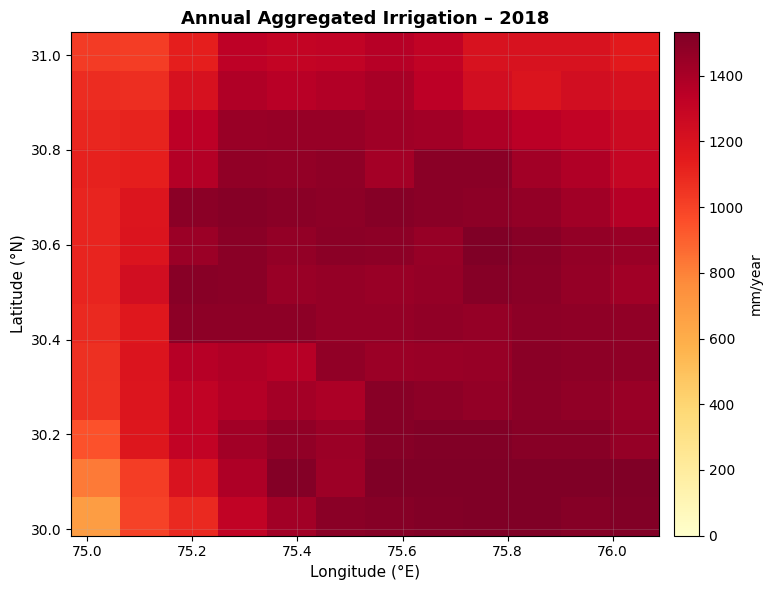

Figure 1 saved → G:\SM2RAIN-irrigation_Final\irrigation_output\figures\annual_irrigation_2018.png


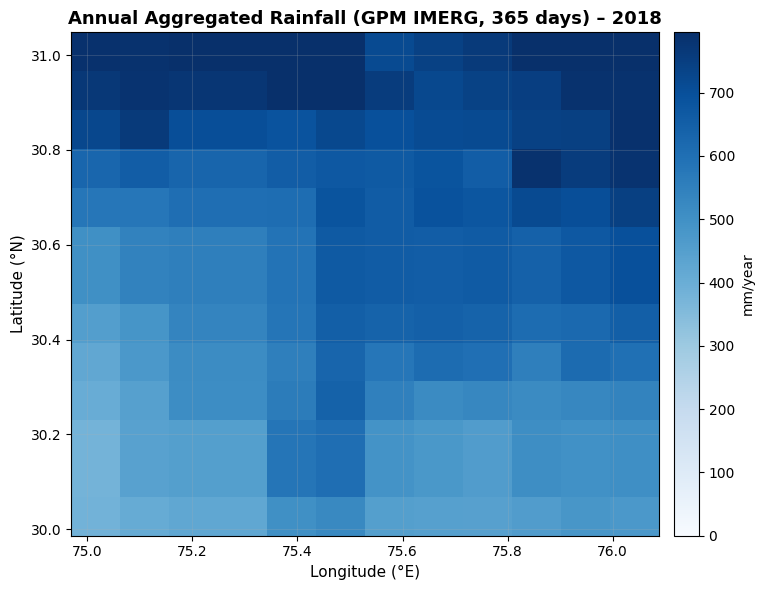

Figure 2 saved → G:\SM2RAIN-irrigation_Final\irrigation_output\figures\annual_rainfall_2018.png


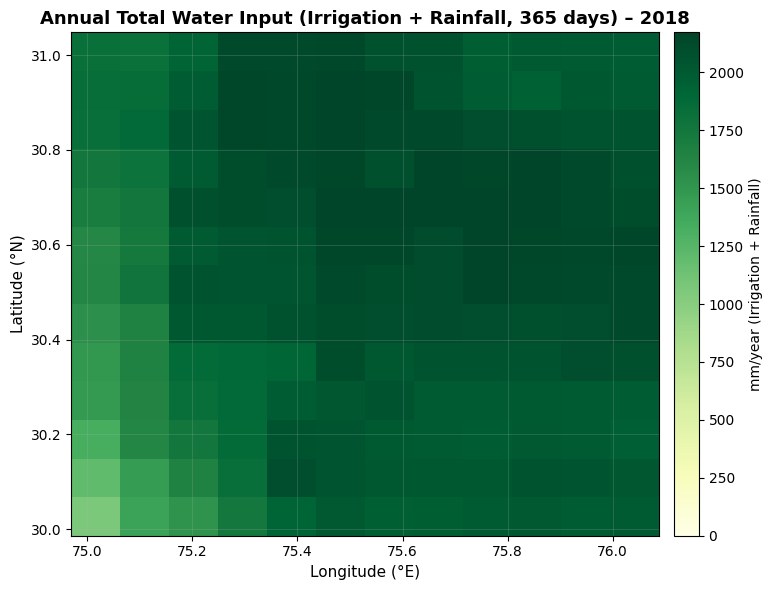

Figure 3 saved → G:\SM2RAIN-irrigation_Final\irrigation_output\figures\annual_total_water_2018.png

  Irrigation  : mean=1368.9  max=1563.7 mm
  Rainfall    : mean=611.9  max=826.0 mm
  Total Water : mean=1980.7  max=2211.3 mm


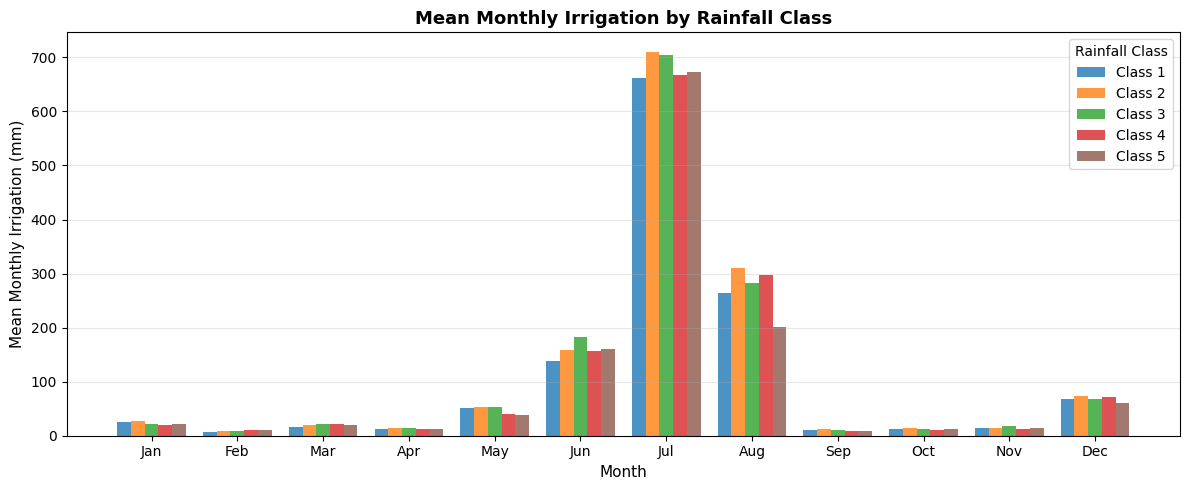

Figure 4 saved → G:\SM2RAIN-irrigation_Final\irrigation_output\figures\monthly_irrigation_by_class.png


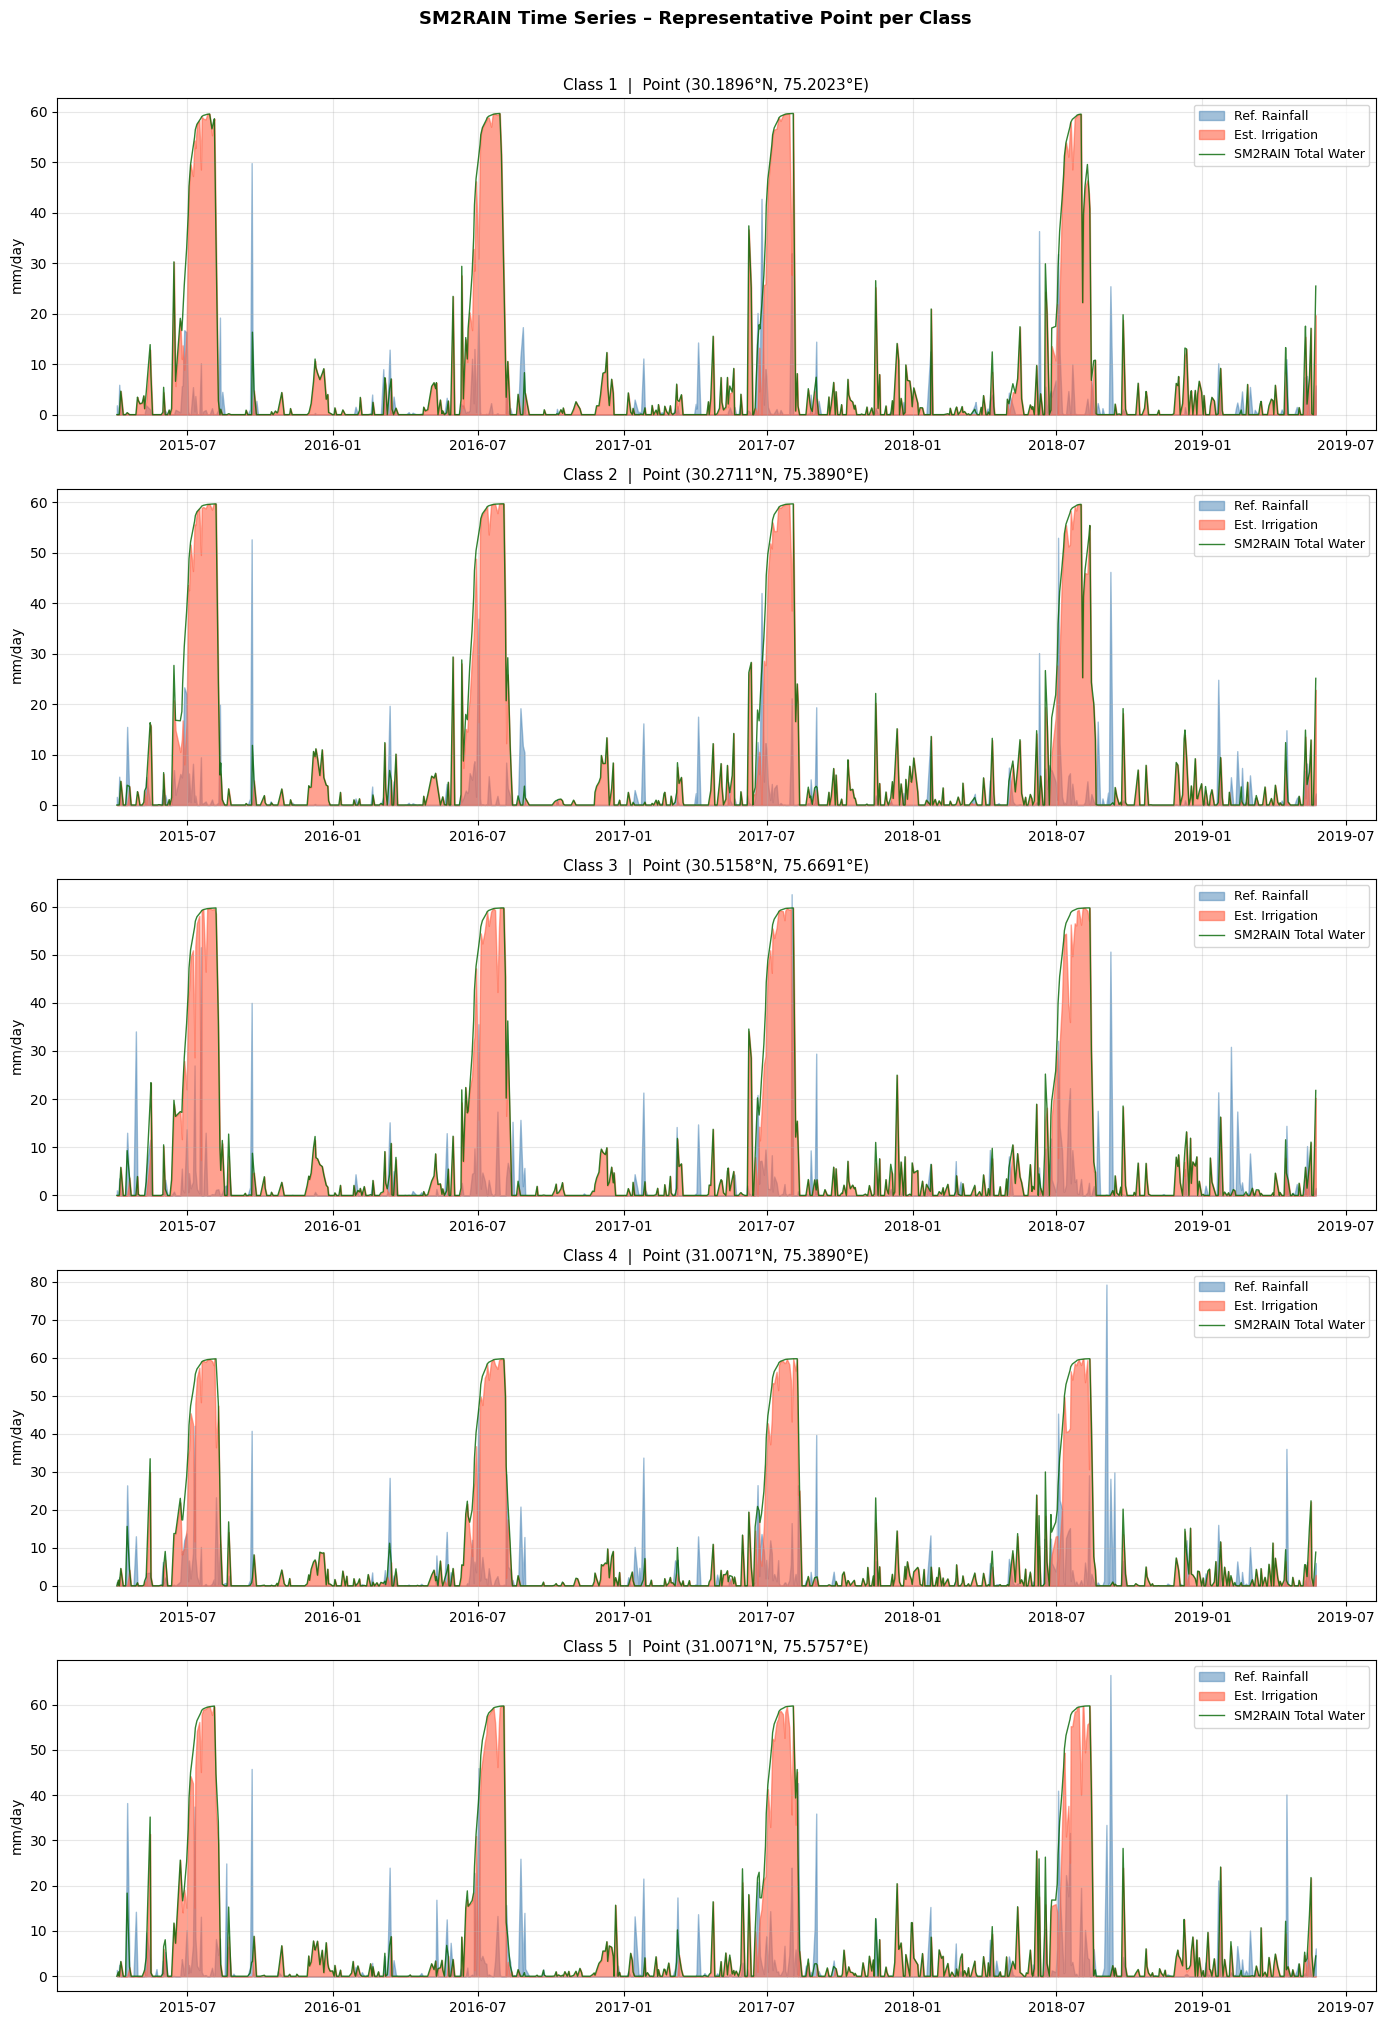

Figure 5 saved → G:\SM2RAIN-irrigation_Final\irrigation_output\figures\sample_time_series_per_class.png


In [72]:
# ── Set the year for the annual aggregated spatial map ───────────────
ANNUAL_PLOT_YEAR = 2018   # ← change to any year in your dataset

# ────────────────────────────────────────────────────────────────────
if len(results_monthly) == 0:
    print("No results to plot yet – run sections 7–10 first.")
else:
    # ── Helper shared by all pcolormesh plots ─────────────────────────
    def _make_pcolormesh_edges(vals_1d_increasing):
        """Return N+1 cell-boundary edges from N sorted centre values."""
        if len(vals_1d_increasing) == 1:
            return np.array([vals_1d_increasing[0] - 0.05,
                             vals_1d_increasing[0] + 0.05])
        half = np.diff(vals_1d_increasing) / 2
        edges = np.concatenate([[vals_1d_increasing[0]  - half[0]],
                                  vals_1d_increasing[:-1] + half,
                                  [vals_1d_increasing[-1] + half[-1]]])
        return edges

    def _build_grid(point_df, col):
        """Pivot (lat, lon, value) → 2-D array + pcolormesh edge meshes."""
        piv = point_df.pivot(index='lat', columns='lon', values=col)
        piv = piv.sort_index(ascending=False)        # north at top
        lats_c = np.sort(piv.index.values)[::-1]     # decreasing
        lons_c = np.sort(piv.columns.values)          # increasing

        lat_edges = _make_pcolormesh_edges(lats_c[::-1])[::-1]  # keep decreasing
        lon_edges = _make_pcolormesh_edges(lons_c)

        lon_e2d, lat_e2d = np.meshgrid(lon_edges, lat_edges)

        lon_min = lon_edges[0];  lon_max = lon_edges[-1]
        lat_min = lat_edges[-1]; lat_max = lat_edges[0]
        return lon_e2d, lat_e2d, piv.values, lon_min, lon_max, lat_min, lat_max

    # ═══════════════════════════════════════════════════════════════════
    # Build annual totals for ANNUAL_PLOT_YEAR
    # ── reference_rain in results_monthly already uses full 365-day
    #    GPM totals (stored in results_monthly_precip_ref), so summing
    #    over months gives the true annual GPM rainfall.
    # ── annual_total_water = annual_irrigation + annual_rainfall
    #    (all 365 days of rain + irrigation on SMAP observation days)
    # ═══════════════════════════════════════════════════════════════════
    annual_rows = []
    for (lat, lon), monthly_df in results_monthly.items():
        df_yr = monthly_df[monthly_df.index.year == ANNUAL_PLOT_YEAR]
        if df_yr.empty:
            continue
        ann_irr  = float(df_yr['estimated_irrigation'].sum())
        ann_rain = float(df_yr['reference_rain'].sum())   # full 365-day GPM total
        annual_rows.append({
            'lat': float(lat),
            'lon': float(lon),
            'annual_irrigation_mm':  ann_irr,
            'annual_rainfall_mm':    ann_rain,
            'annual_total_water_mm': ann_irr + ann_rain,  # irrigation + full-year rainfall
        })

    if not annual_rows:
        print(f"No monthly data found for year {ANNUAL_PLOT_YEAR}. "
              f"Check that results_monthly covers this year.")
    else:
        ann_df = pd.DataFrame(annual_rows)

        # Build shared edge meshes (same grid for all three variables)
        lon_e, lat_e, irr_ann_grid, lon0, lon1, lat0, lat1 = \
            _build_grid(ann_df, 'annual_irrigation_mm')
        _, _, rain_ann_grid, _, _, _, _ = _build_grid(ann_df, 'annual_rainfall_mm')
        _, _, tw_ann_grid,   _, _, _, _ = _build_grid(ann_df, 'annual_total_water_mm')

        # ── Figure 1 – Annual irrigation ─────────────────────────────
        vmax_irr = np.nanquantile(irr_ann_grid, 0.95) or 1
        fig1, ax1 = plt.subplots(figsize=(8, 6))
        pc = ax1.pcolormesh(lon_e, lat_e, irr_ann_grid,
                            cmap='YlOrRd', vmin=0, vmax=vmax_irr, shading='flat')
        plt.colorbar(pc, ax=ax1, pad=0.02, label='mm/year')
        ax1.set_xlim(lon0, lon1); ax1.set_ylim(lat0, lat1)
        ax1.set_xlabel('Longitude (°E)', fontsize=11)
        ax1.set_ylabel('Latitude (°N)',  fontsize=11)
        ax1.set_title(f'Annual Aggregated Irrigation – {ANNUAL_PLOT_YEAR}',
                      fontsize=13, fontweight='bold')
        ax1.grid(True, alpha=0.3, lw=0.5)
        plt.tight_layout()
        out1 = FIGURES_DIR / f'annual_irrigation_{ANNUAL_PLOT_YEAR}.png'
        fig1.savefig(out1, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Figure 1 saved → {out1}")

        # ── Figure 2 – Annual rainfall (all 365 days of GPM) ─────────
        vmax_rain = np.nanquantile(rain_ann_grid, 0.95) or 1
        fig2, ax2b = plt.subplots(figsize=(8, 6))
        pc2 = ax2b.pcolormesh(lon_e, lat_e, rain_ann_grid,
                              cmap='Blues', vmin=0, vmax=vmax_rain, shading='flat')
        plt.colorbar(pc2, ax=ax2b, pad=0.02, label='mm/year')
        ax2b.set_xlim(lon0, lon1); ax2b.set_ylim(lat0, lat1)
        ax2b.set_xlabel('Longitude (°E)', fontsize=11)
        ax2b.set_ylabel('Latitude (°N)',  fontsize=11)
        ax2b.set_title(f'Annual Aggregated Rainfall (GPM IMERG, 365 days) – {ANNUAL_PLOT_YEAR}',
                       fontsize=13, fontweight='bold')
        ax2b.grid(True, alpha=0.3, lw=0.5)
        plt.tight_layout()
        out2b = FIGURES_DIR / f'annual_rainfall_{ANNUAL_PLOT_YEAR}.png'
        fig2.savefig(out2b, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Figure 2 saved → {out2b}")

        # ── Figure 3 – Annual total water input (irrigation + rainfall)
        #    = estimated irrigation (SMAP days) + full-calendar GPM rain
        vmax_tw = np.nanquantile(tw_ann_grid, 0.95) or 1
        fig3b, ax3b = plt.subplots(figsize=(8, 6))
        pc3 = ax3b.pcolormesh(lon_e, lat_e, tw_ann_grid,
                              cmap='YlGn', vmin=0, vmax=vmax_tw, shading='flat')
        plt.colorbar(pc3, ax=ax3b, pad=0.02, label='mm/year (Irrigation + Rainfall)')
        ax3b.set_xlim(lon0, lon1); ax3b.set_ylim(lat0, lat1)
        ax3b.set_xlabel('Longitude (°E)', fontsize=11)
        ax3b.set_ylabel('Latitude (°N)',  fontsize=11)
        ax3b.set_title(f'Annual Total Water Input (Irrigation + Rainfall, 365 days) – {ANNUAL_PLOT_YEAR}',
                       fontsize=13, fontweight='bold')
        ax3b.grid(True, alpha=0.3, lw=0.5)
        plt.tight_layout()
        out3b = FIGURES_DIR / f'annual_total_water_{ANNUAL_PLOT_YEAR}.png'
        fig3b.savefig(out3b, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Figure 3 saved → {out3b}")

        print(f"\n  Irrigation  : mean={ann_df['annual_irrigation_mm'].mean():.1f}  "
              f"max={ann_df['annual_irrigation_mm'].max():.1f} mm")
        print(f"  Rainfall    : mean={ann_df['annual_rainfall_mm'].mean():.1f}  "
              f"max={ann_df['annual_rainfall_mm'].max():.1f} mm")
        print(f"  Total Water : mean={ann_df['annual_total_water_mm'].mean():.1f}  "
              f"max={ann_df['annual_total_water_mm'].max():.1f} mm")

    # ═══════════════════════════════════════════════════════════════════
    # PLOT 4 – Mean monthly irrigation per class (all years)
    # ═══════════════════════════════════════════════════════════════════
    class_monthly_mean = {}
    for (lat, lon), monthly_df in results_monthly.items():
        cid = int(results_daily[(lat, lon)]['class_id'].iloc[0])
        m_df = monthly_df.copy()
        m_df.index = m_df.index.to_timestamp()
        m_df['month'] = m_df.index.month
        class_monthly_mean.setdefault(cid, []).append(m_df[['month', 'estimated_irrigation']])

    fig4, ax4 = plt.subplots(figsize=(12, 5))
    months    = np.arange(1, 13)
    n_classes = len(class_monthly_mean)
    bar_w     = 0.8 / n_classes
    colors    = plt.cm.tab10(np.linspace(0, 0.5, n_classes))

    for i, (cid, dfs) in enumerate(sorted(class_monthly_mean.items())):
        all_pts = pd.concat(dfs, ignore_index=True)
        mean_monthly = all_pts.groupby('month')['estimated_irrigation'].mean().reindex(months, fill_value=0)
        offset = (i - n_classes / 2 + 0.5) * bar_w
        ax4.bar(months + offset, mean_monthly.values, width=bar_w,
                label=f'Class {cid}', alpha=0.8, color=colors[i])

    ax4.set_xticks(months)
    ax4.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])
    ax4.set_xlabel('Month', fontsize=11)
    ax4.set_ylabel('Mean Monthly Irrigation (mm)', fontsize=11)
    ax4.set_title('Mean Monthly Irrigation by Rainfall Class', fontsize=13, fontweight='bold')
    ax4.legend(title='Rainfall Class', fontsize=10)
    ax4.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    out4 = FIGURES_DIR / 'monthly_irrigation_by_class.png'
    fig4.savefig(out4, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure 4 saved → {out4}")

    # ═══════════════════════════════════════════════════════════════════
    # PLOT 5 – Sample time series (one representative point per class)
    # ═══════════════════════════════════════════════════════════════════
    rep_points = {}
    for (lat, lon), daily_df in results_daily.items():
        cid = int(daily_df['class_id'].iloc[0])
        n   = len(daily_df)
        if cid not in rep_points or n > rep_points[cid][2]:
            rep_points[cid] = (lat, lon, n, daily_df)

    n_plots = len(rep_points)
    fig5, axes = plt.subplots(n_plots, 1, figsize=(14, 4 * n_plots), sharex=False)
    if n_plots == 1:
        axes = [axes]

    for ax, (cid, (lat, lon, _, daily_df)) in zip(axes, sorted(rep_points.items())):
        df_plot = daily_df.head(min(730, len(daily_df)))
        ax.fill_between(df_plot.index, df_plot['reference_rain'],
                        alpha=0.5, color='steelblue', label='Ref. Rainfall')
        ax.fill_between(df_plot.index, df_plot['estimated_irrigation'],
                        alpha=0.6, color='tomato',    label='Est. Irrigation')
        ax.plot(df_plot.index, df_plot['total_water_input'],
                color='darkgreen', lw=1.0, label='SM2RAIN Total Water', alpha=0.8)
        ax.set_ylabel('mm/day', fontsize=10)
        ax.set_title(f'Class {cid}  |  Point ({lat:.4f}°N, {lon:.4f}°E)', fontsize=11)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(True, alpha=0.3)

    fig5.suptitle('SM2RAIN Time Series – Representative Point per Class',
                  fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    out5 = FIGURES_DIR / 'sample_time_series_per_class.png'
    fig5.savefig(out5, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure 5 saved → {out5}")


## 12. Spatial Maps for a Selected Month – Irrigation, Rainfall & Total Water Influx


Grid points with data for July 2015: 156
  Irrigation   : min=184.8  max=768.0  mean=666.8 mm
  Rainfall     : min=121.3  max=328.7  mean=161.0 mm
  Total Water  : min=355.3  max=937.0  mean=827.9 mm


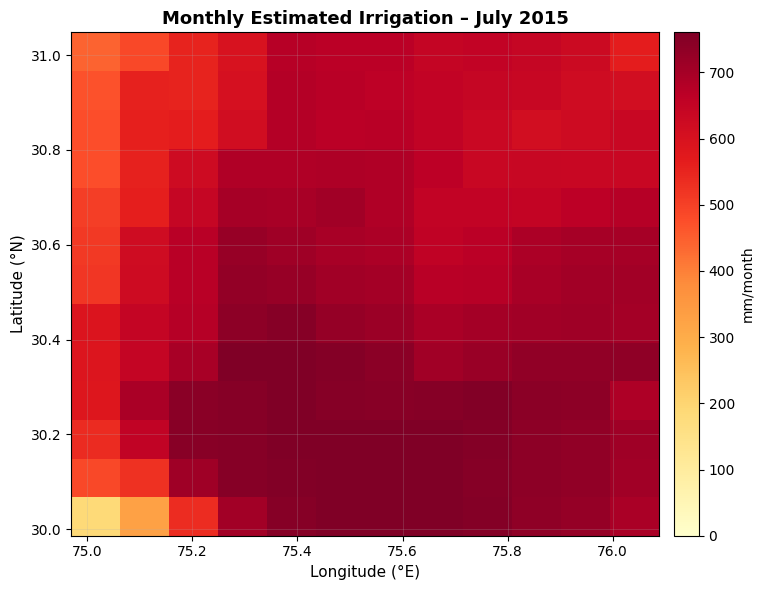

Figure 1 saved → G:\SM2RAIN-irrigation_Final\irrigation_output\figures\monthly_irrigation_2015_07.png


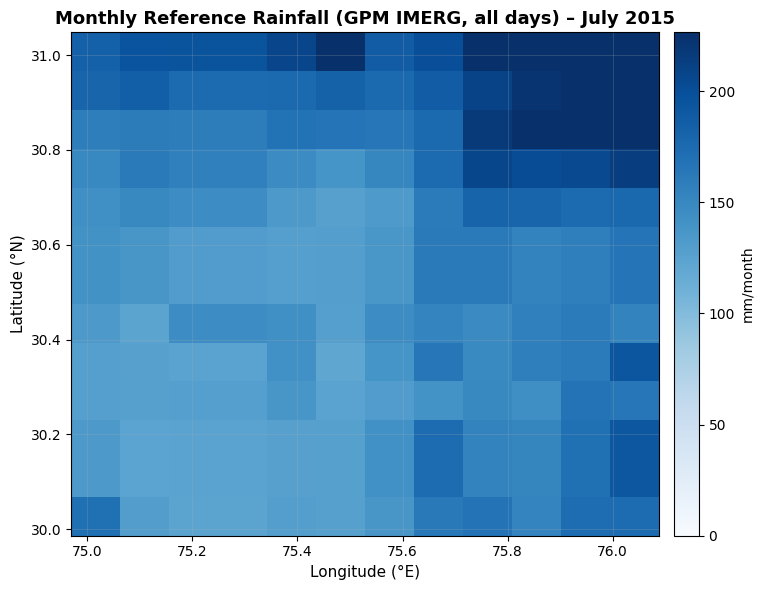

Figure 2 saved → G:\SM2RAIN-irrigation_Final\irrigation_output\figures\monthly_rainfall_2015_07.png


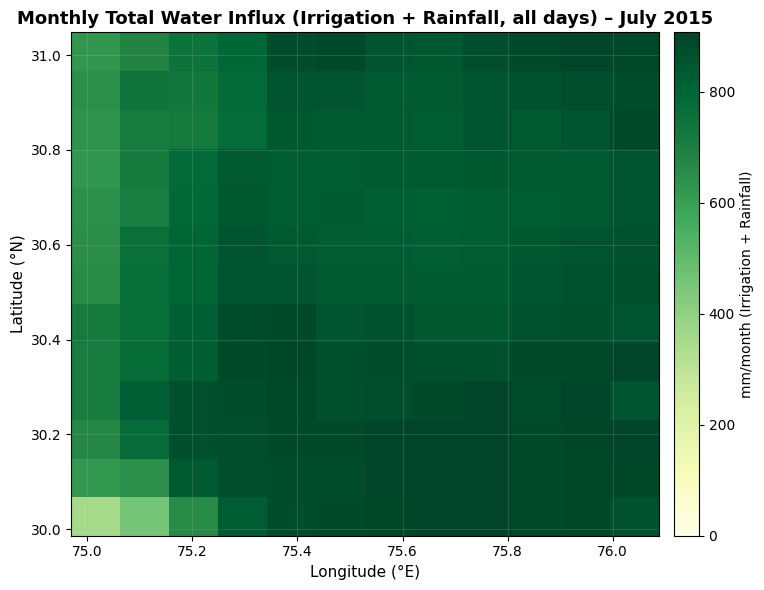

Figure 3 saved → G:\SM2RAIN-irrigation_Final\irrigation_output\figures\monthly_total_water_2015_07.png


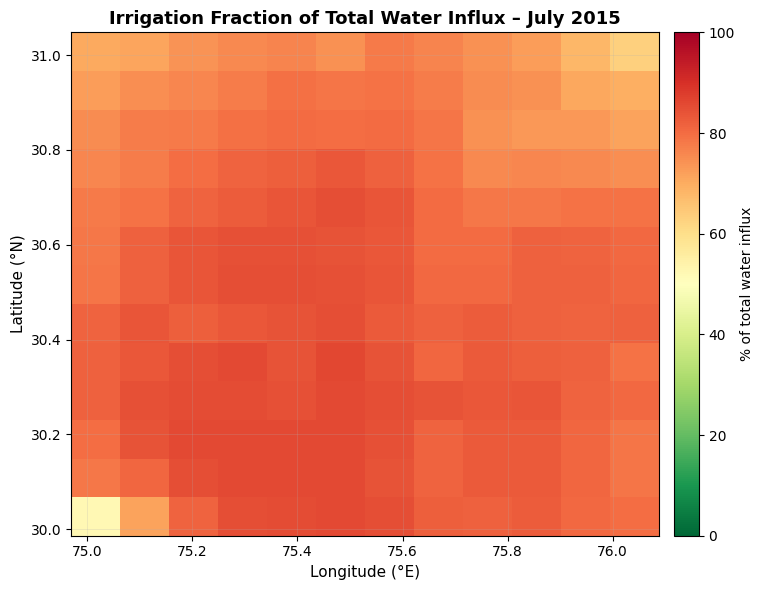

Figure 4 saved → G:\SM2RAIN-irrigation_Final\irrigation_output\figures\monthly_irr_fraction_2015_07.png


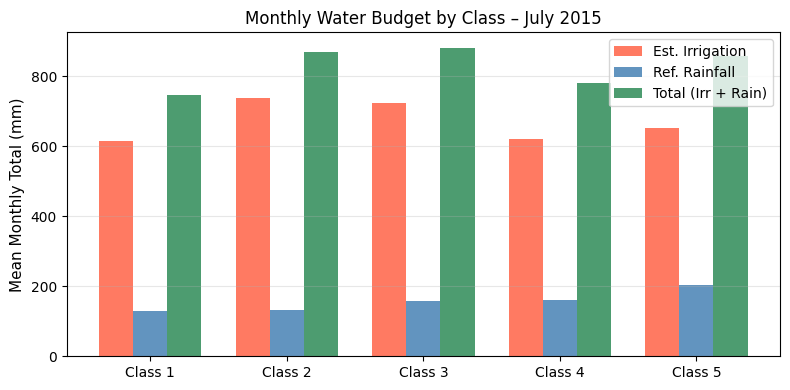

Figure 5 saved → G:\SM2RAIN-irrigation_Final\irrigation_output\figures\monthly_class_budget_2015_07.png


In [74]:

# ── Set the target month here ─────────────────────────────────────────
TARGET_YEAR  = 2015   # ← change to any year in your dataset
TARGET_MONTH = 7    # ← change to 1–12

# ────────────────────────────────────────────────────────────────────
period_label  = f"{TARGET_YEAR}-{TARGET_MONTH:02d}"
target_period = pd.Period(period_label, freq='M')
month_name    = datetime(TARGET_YEAR, TARGET_MONTH, 1).strftime('%B %Y')

# ── Collect one row per grid point for the chosen month ──────────────
# monthly_total_water = irrigation + full-calendar rainfall for the month
# irrigation_fraction = irrigation / (irrigation + rainfall)
rows = []
for (lat, lon), monthly_df in results_monthly.items():
    if target_period in monthly_df.index:
        r      = monthly_df.loc[target_period]
        m_irr  = float(r['estimated_irrigation'])
        m_rain = float(r['reference_rain'])        # full-calendar GPM total for the month
        m_tw   = m_irr + m_rain                    # irrigation + all-days rainfall
        rows.append({
            'lat': float(lat),
            'lon': float(lon),
            'monthly_irrigation_mm':  m_irr,
            'monthly_rainfall_mm':    m_rain,
            'monthly_total_water_mm': m_tw,
            'irrigation_fraction':    m_irr / (m_tw + 1e-6) * 100,  # % of total influx
            'class_id':               int(r['class_id']),
        })

if not rows:
    available = sorted({str(idx) for df in results_monthly.values() for idx in df.index})
    print(f"No data found for {period_label}.")
    print(f"Available periods (sample): {available[:10]} … {available[-5:]}")
else:
    sel_df = pd.DataFrame(rows)
    print(f"Grid points with data for {month_name}: {len(sel_df)}")
    print(f"  Irrigation   : min={sel_df['monthly_irrigation_mm'].min():.1f}  "
          f"max={sel_df['monthly_irrigation_mm'].max():.1f}  "
          f"mean={sel_df['monthly_irrigation_mm'].mean():.1f} mm")
    print(f"  Rainfall     : min={sel_df['monthly_rainfall_mm'].min():.1f}  "
          f"max={sel_df['monthly_rainfall_mm'].max():.1f}  "
          f"mean={sel_df['monthly_rainfall_mm'].mean():.1f} mm")
    print(f"  Total Water  : min={sel_df['monthly_total_water_mm'].min():.1f}  "
          f"max={sel_df['monthly_total_water_mm'].max():.1f}  "
          f"mean={sel_df['monthly_total_water_mm'].mean():.1f} mm")

    # ── Build pcolormesh edges (N+1 boundaries from N sorted centres) ─
    def _make_pcolormesh_edges(centres_1d_sorted):
        c = centres_1d_sorted
        if len(c) == 1:
            return np.array([c[0] - 0.05, c[0] + 0.05])
        half = np.diff(c) / 2.0
        return np.concatenate([[c[0] - half[0]], c[:-1] + half, [c[-1] + half[-1]]])

    def _build_pixel_grid(df, col):
        """Pivot (lat, lon, value) → 2-D array + (N+1)×(M+1) edge meshes."""
        piv      = df.pivot(index='lat', columns='lon', values=col)
        lats_asc = np.sort(piv.index.values)
        lons_asc = np.sort(piv.columns.values)
        piv      = piv.loc[lats_asc[::-1], lons_asc]   # north-first rows

        lat_edges = _make_pcolormesh_edges(lats_asc)[::-1]  # descending
        lon_edges = _make_pcolormesh_edges(lons_asc)         # ascending

        lon_e2d, lat_e2d = np.meshgrid(lon_edges, lat_edges)
        lon0, lon1 = lon_edges[0],   lon_edges[-1]
        lat0, lat1 = lat_edges[-1],  lat_edges[0]
        return lon_e2d, lat_e2d, piv.values, lon0, lon1, lat0, lat1

    # ── Build all four grids ──────────────────────────────────────────
    lon_e, lat_e, irr_grid,  lon0, lon1, lat0, lat1 = _build_pixel_grid(sel_df, 'monthly_irrigation_mm')
    _,     _,     rain_grid, *_                      = _build_pixel_grid(sel_df, 'monthly_rainfall_mm')
    _,     _,     tw_grid,   *_                      = _build_pixel_grid(sel_df, 'monthly_total_water_mm')
    _,     _,     frac_grid, *_                      = _build_pixel_grid(sel_df, 'irrigation_fraction')

    _pmc = dict(shading='flat')   # common pcolormesh kwargs

    # ─────────────────────────────────────────────────────────────────
    # FIGURE 1 – Monthly Estimated Irrigation
    # ─────────────────────────────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(8, 6))
    vmax1 = np.nanquantile(irr_grid[~np.isnan(irr_grid)], 0.95) or 1
    pc1 = ax1.pcolormesh(lon_e, lat_e, irr_grid, cmap='YlOrRd', vmin=0, vmax=vmax1, **_pmc)
    plt.colorbar(pc1, ax=ax1, pad=0.02, label='mm/month')
    ax1.set_xlim(lon0, lon1); ax1.set_ylim(lat0, lat1)
    ax1.set_xlabel('Longitude (°E)', fontsize=11)
    ax1.set_ylabel('Latitude (°N)',  fontsize=11)
    ax1.set_title(f'Monthly Estimated Irrigation – {month_name}', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3, lw=0.5)
    plt.tight_layout()
    out1 = FIGURES_DIR / f'monthly_irrigation_{TARGET_YEAR}_{TARGET_MONTH:02d}.png'
    fig1.savefig(out1, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure 1 saved → {out1}")

    # ─────────────────────────────────────────────────────────────────
    # FIGURE 2 – Monthly Reference Rainfall (all days of the month)
    # ─────────────────────────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    vmax2 = np.nanquantile(rain_grid[~np.isnan(rain_grid)], 0.95) or 1
    pc2 = ax2.pcolormesh(lon_e, lat_e, rain_grid, cmap='Blues', vmin=0, vmax=vmax2, **_pmc)
    plt.colorbar(pc2, ax=ax2, pad=0.02, label='mm/month')
    ax2.set_xlim(lon0, lon1); ax2.set_ylim(lat0, lat1)
    ax2.set_xlabel('Longitude (°E)', fontsize=11)
    ax2.set_ylabel('Latitude (°N)',  fontsize=11)
    ax2.set_title(f'Monthly Reference Rainfall (GPM IMERG, all days) – {month_name}',
                  fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, lw=0.5)
    plt.tight_layout()
    out2 = FIGURES_DIR / f'monthly_rainfall_{TARGET_YEAR}_{TARGET_MONTH:02d}.png'
    fig2.savefig(out2, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure 2 saved → {out2}")

    # ─────────────────────────────────────────────────────────────────
    # FIGURE 3 – Monthly Total Water Influx (Irrigation + Rainfall, all days)
    #   = estimated irrigation (SMAP days) + full-calendar GPM rain
    # ─────────────────────────────────────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(8, 6))
    vmax3 = np.nanquantile(tw_grid[~np.isnan(tw_grid)], 0.95) or 1
    pc3 = ax3.pcolormesh(lon_e, lat_e, tw_grid, cmap='YlGn', vmin=0, vmax=vmax3, **_pmc)
    plt.colorbar(pc3, ax=ax3, pad=0.02, label='mm/month (Irrigation + Rainfall)')
    ax3.set_xlim(lon0, lon1); ax3.set_ylim(lat0, lat1)
    ax3.set_xlabel('Longitude (°E)', fontsize=11)
    ax3.set_ylabel('Latitude (°N)',  fontsize=11)
    ax3.set_title(f'Monthly Total Water Influx (Irrigation + Rainfall, all days) – {month_name}',
                  fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, lw=0.5)
    plt.tight_layout()
    out3 = FIGURES_DIR / f'monthly_total_water_{TARGET_YEAR}_{TARGET_MONTH:02d}.png'
    fig3.savefig(out3, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure 3 saved → {out3}")

    # ─────────────────────────────────────────────────────────────────
    # FIGURE 4 – Irrigation Fraction (%)
    # ─────────────────────────────────────────────────────────────────
    fig4, ax4 = plt.subplots(figsize=(8, 6))
    pc4 = ax4.pcolormesh(lon_e, lat_e, frac_grid, cmap='RdYlGn_r', vmin=0, vmax=100, **_pmc)
    plt.colorbar(pc4, ax=ax4, pad=0.02, label='% of total water influx')
    ax4.set_xlim(lon0, lon1); ax4.set_ylim(lat0, lat1)
    ax4.set_xlabel('Longitude (°E)', fontsize=11)
    ax4.set_ylabel('Latitude (°N)',  fontsize=11)
    ax4.set_title(f'Irrigation Fraction of Total Water Influx – {month_name}',
                  fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3, lw=0.5)
    plt.tight_layout()
    out4 = FIGURES_DIR / f'monthly_irr_fraction_{TARGET_YEAR}_{TARGET_MONTH:02d}.png'
    fig4.savefig(out4, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure 4 saved → {out4}")

    # ─────────────────────────────────────────────────────────────────
    # FIGURE 5 – Class-wise bar chart for the selected month
    # ─────────────────────────────────────────────────────────────────
    fig5, ax5 = plt.subplots(figsize=(8, 4))
    cs = sel_df.groupby('class_id')[
        ['monthly_irrigation_mm', 'monthly_rainfall_mm', 'monthly_total_water_mm']
    ].mean()
    x = np.arange(len(cs)); w = 0.25
    ax5.bar(x - w, cs['monthly_irrigation_mm'],  width=w, label='Est. Irrigation',      color='tomato',    alpha=0.85)
    ax5.bar(x,     cs['monthly_rainfall_mm'],     width=w, label='Ref. Rainfall',        color='steelblue', alpha=0.85)
    ax5.bar(x + w, cs['monthly_total_water_mm'],  width=w, label='Total (Irr + Rain)',   color='seagreen',  alpha=0.85)
    ax5.set_xticks(x)
    ax5.set_xticklabels([f'Class {c}' for c in cs.index])
    ax5.set_ylabel('Mean Monthly Total (mm)', fontsize=11)
    ax5.set_title(f'Monthly Water Budget by Class – {month_name}', fontsize=12)
    ax5.legend(fontsize=10)
    ax5.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    out5 = FIGURES_DIR / f'monthly_class_budget_{TARGET_YEAR}_{TARGET_MONTH:02d}.png'
    fig5.savefig(out5, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure 5 saved → {out5}")


## Completion Summary

This notebook performs end-to-end SM2RAIN irrigation estimation using per-class calibrated parameters.

### What was done
1. **Calibrated parameters loaded** from `per_class_parameters_ludhiana/all_classes_calibration_results.json` — `Zstar`, `Ks`, `lam`, `Kc` for each of the 5 rainfall classes.
2. **SMAP L3 soil moisture** loaded from `SPL3SMP_E_Ludhiana_ROI.nc` (AM/PM averaged where both available).
3. **Grid-point class assignment** via nearest-neighbour lookup (cKDTree) on `SM_classes_ludhiana.csv`.
4. **Temperature & precipitation resampled** to the SMAP grid using cKDTree nearest-neighbour.
5. **SM2RAIN forward model** applied per grid point:
   - Normalise SM → exponential filter (T = 5 days) → `P = Z* dS/dt + Ks S^lam`
   - PET (Hargreaves approx.) → total water = SM2RAIN + Kc × PET
   - Irrigation = max(0, total_water − reference_rainfall)
6. **Daily estimates** saved to `irrigation_output/daily_irrigation_estimates/`
7. **Monthly aggregates** saved to `irrigation_output/monthly_irrigation_estimates/`
8. **Figures** saved to `irrigation_output/figures/`

### Output files
| Dir | File pattern | Contents |
|-----|-------------|---------|
| `daily_irrigation_estimates/` | `daily_irr_lat{lat:.4f}_lon{lon:.4f}.csv` | `date, sm, temp, reference_rain, total_water_input, estimated_irrigation, class_id` |
| `monthly_irrigation_estimates/` | `monthly_irr_lat{lat:.4f}_lon{lon:.4f}.csv` | `year_month, total_water_input, reference_rain, estimated_irrigation, sm_mean, temp_mean, n_obs, class_id, irrigation_fraction` |
| `monthly_irrigation_estimates/` | `all_grid_points_monthly_summary.csv` | Combined summary with `latitude`, `longitude` columns |
| `figures/` | `spatial_mean_annual_irrigation.png` | Spatial scatter map |
| `figures/` | `monthly_irrigation_by_class.png` | Bar chart by class × month |
| `figures/` | `sample_time_series_per_class.png` | Daily time series per class |
